In [1]:
"""
===============================================================================
Comprehensive Benchmark of Advanced Non-Uniform Grids vs. Uniform FFT
===============================================================================
This script tests 4 advanced non-uniform grid topologies against Uniform FFT:
1. Multi-Pole Grid (compound harmonic clustering)
2. Fibonacci / Golden Ratio Grid (low-discrepancy quasi-random)
3. Conformal Warped Grid (deformed harmonic geometry)
4. Chebyshev Angular Grid (algebraic interface clustering)

Runs with:
- One fixed M (varying N)
- One fixed N (varying M)
- Displays interactive plots directly with plt.show()
"""

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Repo Path Setup
# -----------------------------------------------------------------------------
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    set_global_config,
    render_accuracy,
    render_runtime,
    plot_accuracy_comparison,
    plot_runtime_comparison,
)

c:\Users\charl\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =============================================================================
# Domain & Solver Parameters
# =============================================================================
R = 1.0                     # Disk radius
RAD_UNIF = 1                # 1: Uniform radial grid
PROBLEM_TYPE = 0            # 0: Borges & Daripa Problem 1
CUSTOM_PROBLEM = None

# Tolerances & Precision
TOL_NUFFT = 1e-10           # Block CG residual tolerance
MAXITER_NUFFT = 200         # Max CG iterations
EPS_FINUFFT = 1e-12         # 15-digit double-precision
PRECOND_SHIFT = 1e-8        # Regularization shift for circulant preconditioner
KDE_OVERSAMPLE = 4          # 4x fine grid FFT-KDE oversampling
KDE_BANDWIDTH = 1.0         # Gaussian bandwidth multiplier sigma = 2*pi/N
QUAD_RULE = 1               # 1: Trapezoidal, 2: Simpson
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann

# Sweep Grid Resolutions
N_vals = [32, 64, 128, 256, 512]
M_vals = [32, 64, 128, 256, 512]

# Single Fixed Values
FIXED_M = 128               # Fixed radial resolution for varying N sweep
FIXED_N = 128               # Fixed angular resolution for varying M sweep

MUTE_OUTPUT = True

# =============================================================================
# Method Suite: 5 Advanced Grids + Uniform Reference
# =============================================================================
METHODS = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Unif-NUDFT", label="Uniform / NUDFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=True),
    dict(name="Unif-NUFFT", label="Uniform / NUFFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=False),
]

ADVANCED_KINDS = [
    ("multipole", "Multi-Pole"),
    ("fibonacci", "Fibonacci (Golden Ratio)"),
    ("warped", "Harmonic Warped"),
    ("chebyshev", "Chebyshev Angular"),
]

for kind_id, kind_name in ADVANCED_KINDS:
    METHODS += [
        dict(name=f"Fixed-{kind_id}-NUDFT", label=f"Fixed {kind_name} / NUDFT", azu_unif=1, mesh_kind=kind_id, solver_azu_unif=1, use_nudft=True),
        dict(name=f"Fixed-{kind_id}-NUFFT", label=f"Fixed {kind_name} / NUFFT", azu_unif=1, mesh_kind=kind_id, solver_azu_unif=1, use_nudft=False),
    ]

# =============================================================================
# Regularization Lambdas for Advanced Grids
# =============================================================================
BASE_MACHINE_PRECS = {
    "Unif-FFT": 0.0,
    "Unif-NUDFT": 1e-20,
    "Unif-NUFFT": 1e-20,
    "Fixed-fibonacci-NUDFT": 1e-16,
    "Fixed-fibonacci-NUFFT": 1e-12,
}

# 1. Sweep: Varying N (with Fixed M = 128)
LAMBDAS_VARY_N = {
    **BASE_MACHINE_PRECS,
    "Fixed-multipole-NUDFT":   {32: 1e-16, 64: 1e-16, 128: 1e-12, 256: 1e-11, 512: 1e-10},
    "Fixed-multipole-NUFFT":   1e-12,
    "Fixed-warped-NUDFT":      {32: 1e-16, 64: 1e-16, 128: 1e-12, 256: 1e-11, 512: 1e-10},
    "Fixed-warped-NUFFT":      1e-12,
    "Fixed-chebyshev-NUDFT":   {32: 1e-16, 64: 1e-12, 128: 1e-11, 256: 1e-12, 512: 1e-11},
    "Fixed-chebyshev-NUFFT":   1e-12,
}

# 2. Sweep: Varying M (with Fixed N = 128)
LAMBDAS_VARY_M = {
    **BASE_MACHINE_PRECS,
    "Fixed-multipole-NUDFT":   1e-12,
    "Fixed-multipole-NUFFT":   1e-12,
    "Fixed-warped-NUDFT":      1e-12,
    "Fixed-warped-NUFFT":      1e-12,
    "Fixed-chebyshev-NUDFT":   1e-11,
    "Fixed-chebyshev-NUFFT":   1e-12,
}

set_global_config(
        R=R,
        rad_unif=RAD_UNIF,
        tol_nufft=TOL_NUFFT,
        maxiter_nufft=MAXITER_NUFFT,
        eps_finufft=EPS_FINUFFT,
        precond_shift=PRECOND_SHIFT,
        kde_oversample=KDE_OVERSAMPLE,
        kde_bandwidth=KDE_BANDWIDTH,
        quad_rule=QUAD_RULE,
        BC_choice=BC_CHOICE,
        problem_type=PROBLEM_TYPE,
        custom_problem=CUSTOM_PROBLEM,
    )

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 1. Sweep: Varying N (Fixed M)
print(f"\n[1/2] Running Sweep: Varying N with Fixed M={FIXED_M}...")
df_vary_N = run_tests_pipeline(
    N_vals,
    None,
    fixed_other=FIXED_M,
    methods=METHODS,
    test_type="Accuracy_VaryN",
    reg_param=LAMBDAS_VARY_N,
    mute=MUTE_OUTPUT,
)

# 2. Sweep: Varying M (Fixed N)
print(f"\n[2/2] Running Sweep: Varying M with Fixed N={FIXED_N}...")
df_vary_M = run_tests_pipeline(
    None,
    M_vals,
    fixed_other=FIXED_N,
    methods=METHODS,
    test_type="Accuracy_VaryM",
    reg_param=LAMBDAS_VARY_M,
    mute=MUTE_OUTPUT,
)


[1/2] Running Sweep: Varying N with Fixed M=128...


Pipeline (Accuracy_VaryN): 100%|██████████| 11/11 [00:15<00:00,  1.44s/it, method=Fixed-chebyshev-NUFFT]



[2/2] Running Sweep: Varying M with Fixed N=128...


Pipeline (Accuracy_VaryM): 100%|██████████| 11/11 [00:24<00:00,  2.23s/it, method=Fixed-chebyshev-NUFFT]



Accuracy Comparison (Fixed M=128)

Accuracy (Fixed M=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed Chebyshev Angular / NUDFT,Fixed Fibonacci (Golden Ratio) / NUDFT,Fixed Harmonic Warped / NUDFT,Fixed Multi-Pole / NUDFT,Fixed Chebyshev Angular / NUFFT,Fixed Fibonacci (Golden Ratio) / NUFFT,Fixed Harmonic Warped / NUFFT,Fixed Multi-Pole / NUFFT
N,,,,,,,,,,,
32,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.54e-07,6.55e-07,6.55e-07,6.55e-07,6.54e-07,6.55e-07,6.55e-07
64,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.56e-07,6.55e-07,6.55e-07,6.55e-07
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,6.55e-07,6.55e-07,6.55e-07,7.04e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
512,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07



Accuracy Comparison (Fixed N=128)

Accuracy (Fixed N=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed Chebyshev Angular / NUDFT,Fixed Fibonacci (Golden Ratio) / NUDFT,Fixed Harmonic Warped / NUDFT,Fixed Multi-Pole / NUDFT,Fixed Chebyshev Angular / NUFFT,Fixed Fibonacci (Golden Ratio) / NUFFT,Fixed Harmonic Warped / NUFFT,Fixed Multi-Pole / NUFFT
M,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07
512,4.04e-08,4.04e-08,4.04e-08,4.05e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08



Runtime Comparison (Fixed M=128)

Runtime (Fixed M=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed Chebyshev Angular / NUDFT,Fixed Fibonacci (Golden Ratio) / NUDFT,Fixed Harmonic Warped / NUDFT,Fixed Multi-Pole / NUDFT,Fixed Chebyshev Angular / NUFFT,Fixed Fibonacci (Golden Ratio) / NUFFT,Fixed Harmonic Warped / NUFFT,Fixed Multi-Pole / NUFFT
N,,,,,,,,,,,
32,0.0849,0.0081,0.0244,0.0064,0.0083,0.0078,0.0054,0.1100,0.2376,0.0904,0.0858
64,0.0041,0.0109,0.0265,0.0114,0.0117,0.0112,0.0125,0.1077,0.5104,0.0248,0.1201
128,0.0048,0.0422,0.0748,0.0525,0.0523,0.0467,0.0461,0.0971,2.5615,0.0664,0.1208
256,0.0082,0.1089,0.0685,0.1430,0.1536,0.1421,0.1508,0.0691,2.4299,0.0890,0.0870
512,0.0192,0.3672,0.0852,0.5349,0.5690,0.5579,0.5193,0.0913,3.8857,0.0909,0.0998



Runtime Comparison (Fixed N=128)

Runtime (Fixed N=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed Chebyshev Angular / NUDFT,Fixed Fibonacci (Golden Ratio) / NUDFT,Fixed Harmonic Warped / NUDFT,Fixed Multi-Pole / NUDFT,Fixed Chebyshev Angular / NUFFT,Fixed Fibonacci (Golden Ratio) / NUFFT,Fixed Harmonic Warped / NUFFT,Fixed Multi-Pole / NUFFT
M,,,,,,,,,,,
32,0.0020,0.0332,0.0362,0.0340,0.0365,0.0393,0.0356,0.0467,0.6304,0.0334,0.0431
64,0.0044,0.0325,0.0393,0.0406,0.0388,0.0348,0.0347,0.0637,1.1363,0.0428,0.0598
128,0.0095,0.0359,0.0658,0.0468,0.0499,0.0455,0.0443,0.1066,1.9648,0.0674,0.0960
256,0.0071,0.0532,0.1161,0.0701,0.0779,0.0679,0.0716,0.2044,3.3156,0.1205,0.1668
512,0.0188,0.0800,0.2311,0.1366,0.1255,0.1226,0.1159,0.3843,12.1014,0.2304,0.4563



Displaying Comparison Plots...


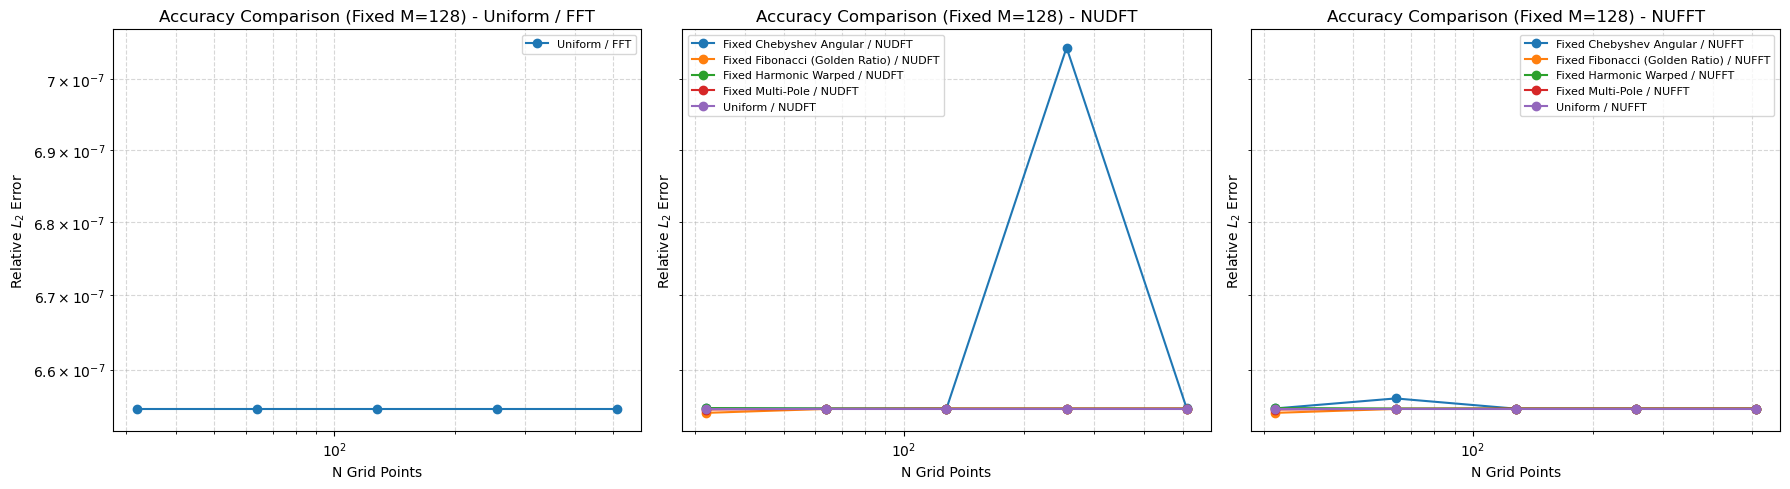

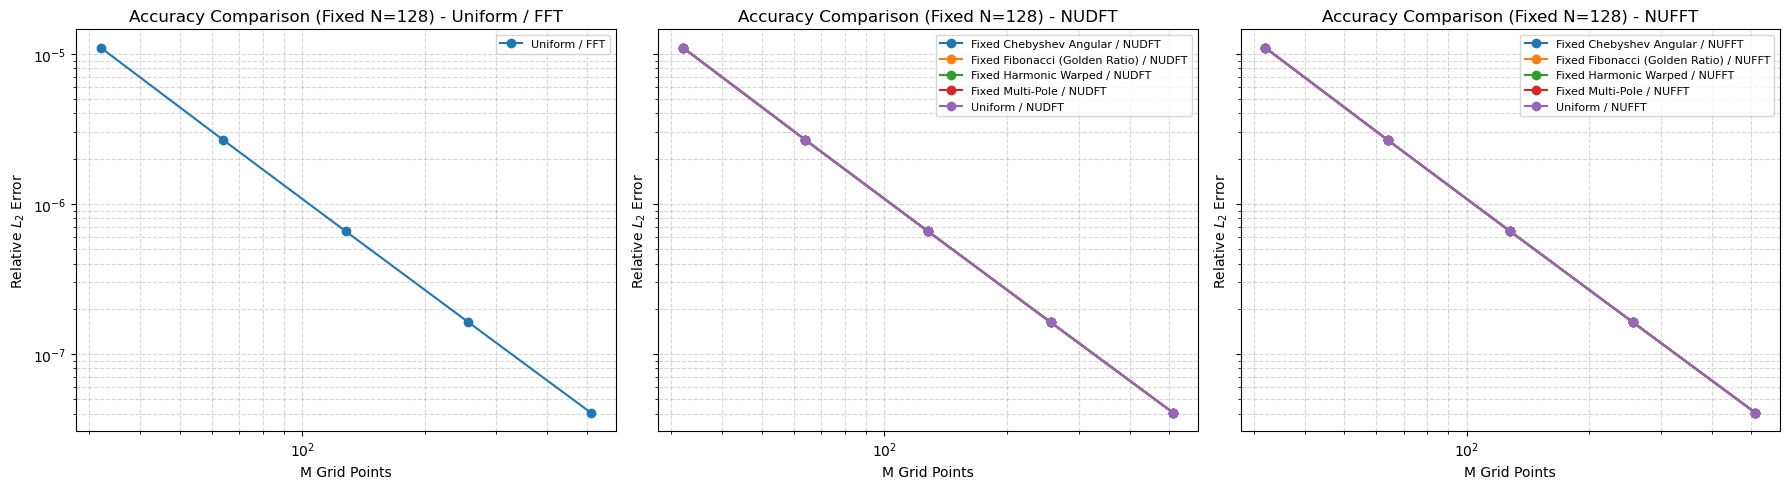


Benchmark Complete.


In [4]:
# 3. Print Results Tables
print("\n" + "=" * 80)
print(f"Accuracy Comparison (Fixed M={FIXED_M})")
print("=" * 80)
render_accuracy(df_vary_N, index_col="N", columns_col="label", title_prefix=f"Accuracy (Fixed M={FIXED_M})")

print("\n" + "=" * 80)
print(f"Accuracy Comparison (Fixed N={FIXED_N})")
print("=" * 80)
render_accuracy(df_vary_M, index_col="M", columns_col="label", title_prefix=f"Accuracy (Fixed N={FIXED_N})")

print("\n" + "=" * 80)
print(f"Runtime Comparison (Fixed M={FIXED_M})")
print("=" * 80)
render_runtime(df_vary_N, index_col="N", columns_col="label", title_prefix=f"Runtime (Fixed M={FIXED_M})")

print("\n" + "=" * 80)
print(f"Runtime Comparison (Fixed N={FIXED_N})")
print("=" * 80)
render_runtime(df_vary_M, index_col="M", columns_col="label", title_prefix=f"Runtime (Fixed N={FIXED_N})")

# 4. Display Plots Interactively
print("\nDisplaying Comparison Plots...")

# Plot 1: Accuracy (Varying N)
plot_accuracy_comparison(df_vary_N, index_col="N", title_prefix=f"Accuracy Comparison (Fixed M={FIXED_M})")
plt.show()

# Plot 2: Accuracy (Varying M)
plot_accuracy_comparison(df_vary_M, index_col="M", title_prefix=f"Accuracy Comparison (Fixed N={FIXED_N})")
plt.show()



print("\nBenchmark Complete.")

